# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [1]:
!pip install mat73 h5py

pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.11.6
  3.11.6/envs/fast-rag-out-311
  3.11.8
  fast-rag-out-311

Note: See 'pyenv help global' for tips on allowing both
      python2 and python3 to be found.


In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [5]:
# 데이터 경로 설정 (상대경로)
import os

DATA_DIR = "./data"

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {os.path.abspath(DATA_DIR)}")
print(f"파일 목록 :")

for f in files:
    size_gb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_gb:.1f} GB)")

데이터 경로 : /Users/gimminjae/Desktop/skala_실습/ds_project/data
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [6]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [5]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [6]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [7]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [8]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [9]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [10]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [11]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [12]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


## Question 3

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d

def safe_array(x):
    arr = np.asarray(x).squeeze()
    if arr.ndim == 0:
        arr = np.array([arr])
    return arr

def get_policy(cell):
    return str(cell.get('policy_readable') or cell.get('policy') or 'unknown')

def get_cycle_map(cell):
    """
    한 셀의 cycles를 '실제 cycle 번호 -> cycle dict' 형태로 매핑
    batch에 따라 cycle 1 상세 데이터가 없을 수 있으므로 보정
    """
    cycles_raw = cell['cycles']
    cycles = to_list_of_dicts(cycles_raw)

    summary = cell['summary']
    summary_cycle = safe_array(summary['cycle']).astype(int)

    cycle_map = {}

    # 가장 이상적인 경우
    if len(summary_cycle) == len(cycles):
        for cyc_num, cyc_obj in zip(summary_cycle, cycles):
            cycle_map[int(cyc_num)] = cyc_obj
        return cycle_map

    # cycle 1 상세 데이터가 빠진 경우 대응
    if len(summary_cycle) == len(cycles) + 1:
        for cyc_num, cyc_obj in zip(summary_cycle[1:], cycles):
            cycle_map[int(cyc_num)] = cyc_obj
        return cycle_map

    # fallback
    for i, cyc_obj in enumerate(cycles):
        cycle_map[i + 1] = cyc_obj
    return cycle_map

def area_trapz(y, x):
    """numpy 버전 차이 대응"""
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, x)
    elif hasattr(np, "trapz"):
        return np.trapz(y, x)
    else:
        return np.nan

In [14]:
def extract_delta_q_with_sign(batch, cycle_a=10, cycle_b=100):
    records = []
    curve_dict = {}

    for cell_id, cell in enumerate(batch):
        try:
            cycle_map = get_cycle_map(cell)

            if cycle_a not in cycle_map or cycle_b not in cycle_map:
                continue

            c_a = cycle_map[cycle_a]
            c_b = cycle_map[cycle_b]

            q_a = safe_array(c_a['Qdlin']).astype(float)
            q_b = safe_array(c_b['Qdlin']).astype(float)
            v   = safe_array(cell['Vdlin']).astype(float)

            if len(q_a) != len(v) or len(q_b) != len(v):
                continue

            delta_q = q_b - q_a

            mid_mask = (v >= 2.5) & (v < 3.0)

            idx_abs_max = np.argmax(np.abs(delta_q))

            records.append({
                'cell_id': cell_id,
                'cycle_life': int(np.asarray(cell['cycle_life']).squeeze()),
                'charging_policy': get_policy(cell),

                # 🔥 원래 값
                'Q10_mean': np.mean(q_a),
                'Q100_mean': np.mean(q_b),

                # 🔥 차이 (부호 유지)
                'delta_q_mean': np.mean(delta_q),
                'delta_q_mid_mean': np.mean(delta_q[mid_mask]) if mid_mask.sum() > 0 else np.nan,

                # 🔥 크기
                'delta_q_abs_mean': np.mean(np.abs(delta_q)),

                # 🔥 위치
                'delta_q_peak_voltage': v[idx_abs_max],
                'delta_q_peak_value': delta_q[idx_abs_max],
            })

            curve_dict[cell_id] = {
                'V': v,
                'Qdlin_10': q_a,
                'Qdlin_100': q_b,
                'delta_q': delta_q
            }

        except Exception as e:
            print(f"[WARN] cell_id={cell_id} 처리 실패: {e}")

    return pd.DataFrame(records), curve_dict


delta_q_df2, delta_q_curves2 = extract_delta_q_with_sign(batch)

delta_q_df2 = delta_q_df2.drop_duplicates(subset=['cell_id'])
print(f"ΔQ(V) Feature Dataset Shape : {delta_q_df2.shape}")
display(delta_q_df2)

ΔQ(V) Feature Dataset Shape : (46, 10)


,cell_id,cycle_life,charging_policy,Q10_mean,Q100_mean,delta_q_mean,delta_q_mid_mean,delta_q_abs_mean,delta_q_peak_voltage,delta_q_peak_value
0,0,1190,3.6C(80%)-3.6C,0.748177,0.745303,-0.002873,-0.005581,0.002955,3.064565,-0.008460
1,1,1179,3.6C(80%)-3.6C,0.750568,0.746469,-0.004100,-0.006305,0.004100,3.136637,-0.011004
2,2,1177,3.6C(80%)-3.6C,0.755418,0.750931,-0.004487,-0.006363,0.004487,3.153153,-0.017216
3,3,1226,4C(80%)-4C,0.757228,0.749772,-0.007456,-0.012805,0.007468,2.957958,-0.018961
4,4,1227,4C(80%)-4C,0.750583,0.744833,-0.005750,-0.010376,0.005751,2.878378,-0.013958
5,5,1074,4.4C(80%)-4.4C,0.745617,0.734543,-0.011074,-0.019417,0.011095,2.872372,-0.025179
6,6,636,4.8C(80%)-4.8C,0.750677,0.734712,-0.015965,-0.026693,0.015971,2.933934,-0.037886
7,7,870,4.8C(80%)-4.8C,0.767326,0.750680,-0.016646,-0.025750,0.016646,3.060060,-0.038233
8,8,879,5.4C(40%)-3.6C,0.762164,0.749345,-0.012819,-0.022105,0.012819,2.941441,-0.030808
9,9,1054,5.4C(40%)-3.6C,0.759926,0.748415,-0.011511,-0.019606,0.011511,2.968468,-0.028724


===== 기본 정보 =====
전체 셀 수       : 46
장수명 셀 수     : 10
단수명 셀 수     : 10
중간 수명 셀 수  : 26

===== 장수명 vs 단수명 평균 비교 =====


life_group,long,short,diff_long_minus_short
delta_q_mean,-0.008682,-0.024812,0.016130
delta_q_mid_mean,-0.014668,-0.040536,0.025868
delta_q_abs_mean,0.008694,0.024814,-0.016120
delta_q_peak_value,-0.021380,-0.052723,0.031343



===== cycle_life와 feature 상관관계 =====


,corr_with_cycle_life
delta_q_peak_value,0.8816
delta_q_mid_mean,0.8720
delta_q_mean,0.8538
delta_q_abs_mean,-0.8538


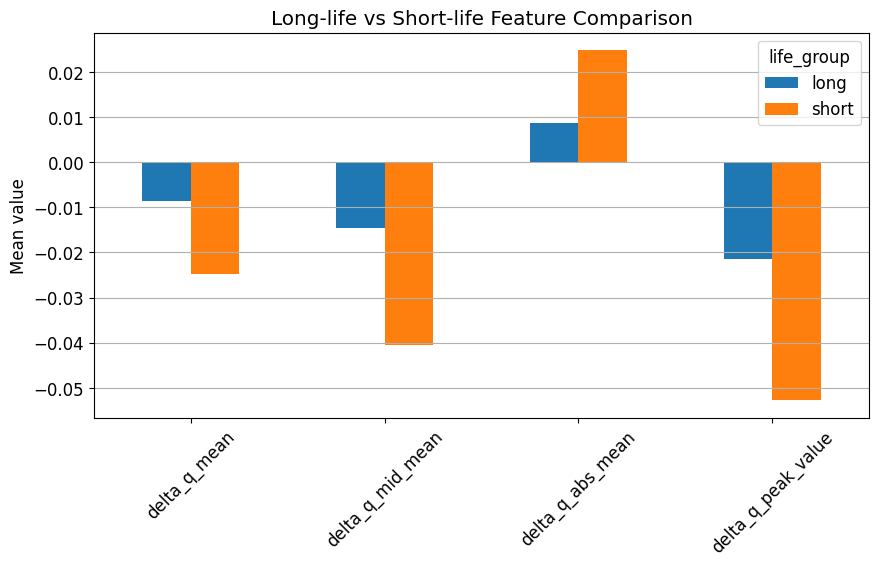

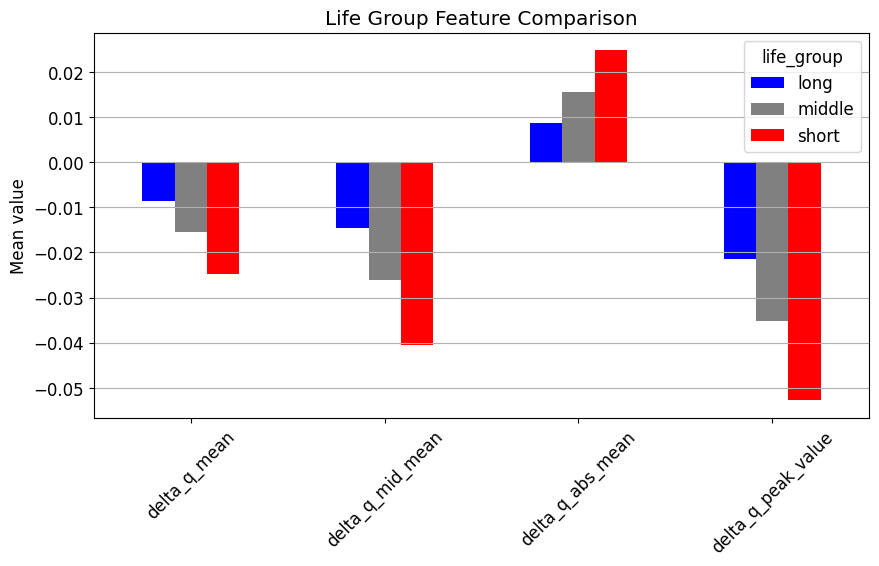

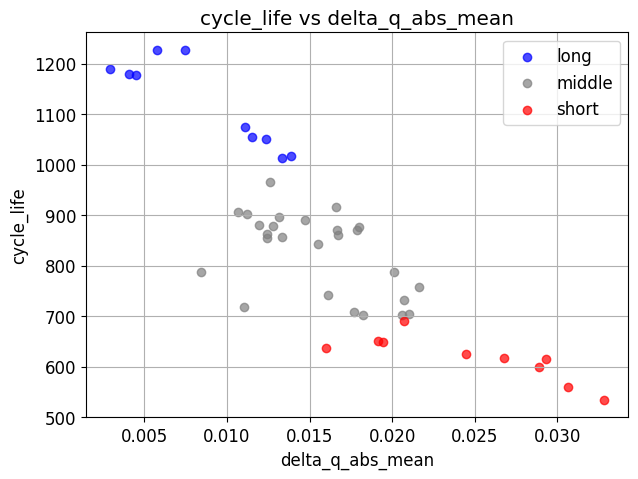

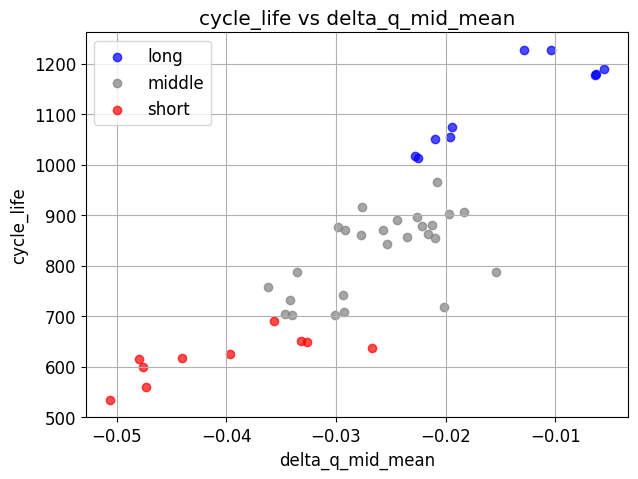


===== 자동 해석 요약 =====
- 장수명 셀의 delta_q_abs_mean 평균: 0.008694
- 단수명 셀의 delta_q_abs_mean 평균: 0.024814
- 장수명 셀의 delta_q_mid_mean 평균: -0.014668
- 단수명 셀의 delta_q_mid_mean 평균: -0.040536
- 장수명 셀의 delta_q_peak_value 평균: -0.021380
- 단수명 셀의 delta_q_peak_value 평균: -0.052723


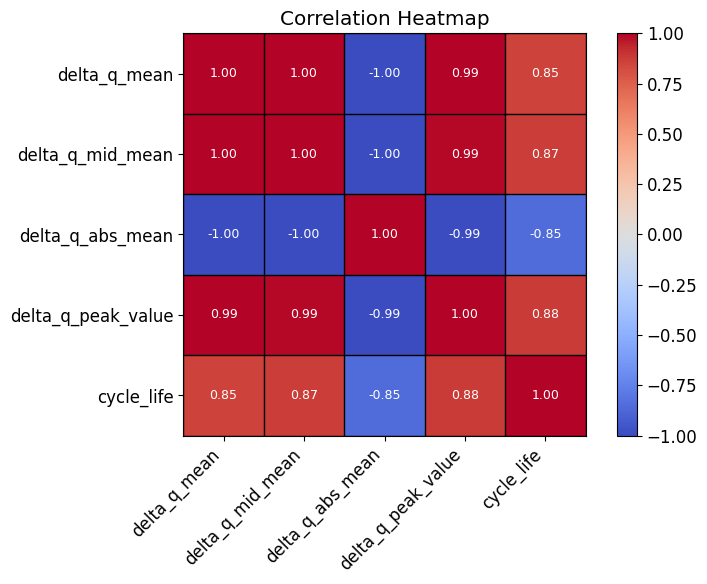

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 0. 기준 설정
# --------------------------------------------------
LONG_LIFE_TH = 1000
SHORT_LIFE_TH = 700

analysis_df = delta_q_df2.copy()

analysis_df["life_group"] = np.where(
    analysis_df["cycle_life"] > LONG_LIFE_TH, "long",
    np.where(analysis_df["cycle_life"] < SHORT_LIFE_TH, "short", "middle")
)

print("===== 기본 정보 =====")
print(f"전체 셀 수       : {len(analysis_df)}")
print(f"장수명 셀 수     : {(analysis_df['life_group'] == 'long').sum()}")
print(f"단수명 셀 수     : {(analysis_df['life_group'] == 'short').sum()}")
print(f"중간 수명 셀 수  : {(analysis_df['life_group'] == 'middle').sum()}")

# --------------------------------------------------
# 1. 장수명 vs 단수명 평균 비교
# --------------------------------------------------
feature_cols = [
    "delta_q_mean",
    "delta_q_mid_mean",
    "delta_q_abs_mean",
    "delta_q_peak_value"
]

group_compare = (
    analysis_df[analysis_df["life_group"].isin(["long", "short"])]
    .groupby("life_group")[feature_cols]
    .mean()
    .T
)

group_compare["diff_long_minus_short"] = group_compare["long"] - group_compare["short"]

print("\n===== 장수명 vs 단수명 평균 비교 =====")
display(group_compare.round(6))

# --------------------------------------------------
# 2. 수명과 feature 상관관계
# --------------------------------------------------
corr_df = (
    analysis_df[feature_cols + ["cycle_life"]]
    .corr()[["cycle_life"]]
    .drop(index="cycle_life")
    .rename(columns={"cycle_life": "corr_with_cycle_life"})
    .sort_values("corr_with_cycle_life", key=lambda s: s.abs(), ascending=False)
)

print("\n===== cycle_life와 feature 상관관계 =====")
display(corr_df.round(4))

# --------------------------------------------------
# 3. 시각화 1: 장수명 vs 단수명 feature 막대그래프
# --------------------------------------------------
plot_df = (
    analysis_df[analysis_df["life_group"].isin(["long", "short"])]
    .groupby("life_group")[feature_cols]
    .mean()
    .T
)

plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Long-life vs Short-life Feature Comparison")
plt.ylabel("Mean value")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


# --------------------------------------------------
# 3. 시각화 1: 장수명 vs 단수명 feature 막대그래프
# --------------------------------------------------
plot_df = (
    analysis_df
    .groupby("life_group")[feature_cols]
    .mean()
    .T
)

plot_df = plot_df[["long", "middle", "short"]]  # 순서 고정

plot_df.plot(
    kind="bar",
    figsize=(10, 5),
    color=["blue", "gray", "red"]  # long / middle / short
)

plt.title("Life Group Feature Comparison")
plt.ylabel("Mean value")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

# --------------------------------------------------
# 4. 시각화 2: scatter plot
# --------------------------------------------------
plt.figure(figsize=(7, 5))

colors = {"long": "blue", "middle": "gray", "short": "red"}

for group in ["long", "middle", "short"]:
    subset = analysis_df[analysis_df["life_group"] == group]
    plt.scatter(
        subset["delta_q_abs_mean"],
        subset["cycle_life"],
        label=group,
        color=colors[group],
        alpha=0.7
    )

plt.xlabel("delta_q_abs_mean")
plt.ylabel("cycle_life")
plt.title("cycle_life vs delta_q_abs_mean")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))

colors = {"long": "blue", "middle": "gray", "short": "red"}

for group in ["long", "middle", "short"]:
    subset = analysis_df[analysis_df["life_group"] == group]
    plt.scatter(
        subset["delta_q_mid_mean"],
        subset["cycle_life"],
        label=group,
        color=colors[group],
        alpha=0.7
    )

plt.xlabel("delta_q_mid_mean")
plt.ylabel("cycle_life")
plt.title("cycle_life vs delta_q_mid_mean")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# 5. 자동 해석용 요약 문장 만들기
# --------------------------------------------------
long_short = analysis_df[analysis_df["life_group"].isin(["long", "short"])]

if len(long_short["life_group"].unique()) == 2:
    long_mean = long_short[long_short["life_group"] == "long"]["delta_q_abs_mean"].mean()
    short_mean = long_short[long_short["life_group"] == "short"]["delta_q_abs_mean"].mean()

    mid_long = long_short[long_short["life_group"] == "long"]["delta_q_mid_mean"].mean()
    mid_short = long_short[long_short["life_group"] == "short"]["delta_q_mid_mean"].mean()

    peak_long = long_short[long_short["life_group"] == "long"]["delta_q_peak_value"].mean()
    peak_short = long_short[long_short["life_group"] == "short"]["delta_q_peak_value"].mean()

    print("\n===== 자동 해석 요약 =====")
    print(f"- 장수명 셀의 delta_q_abs_mean 평균: {long_mean:.6f}")
    print(f"- 단수명 셀의 delta_q_abs_mean 평균: {short_mean:.6f}")
    print(f"- 장수명 셀의 delta_q_mid_mean 평균: {mid_long:.6f}")
    print(f"- 단수명 셀의 delta_q_mid_mean 평균: {mid_short:.6f}")
    print(f"- 장수명 셀의 delta_q_peak_value 평균: {peak_long:.6f}")
    print(f"- 단수명 셀의 delta_q_peak_value 평균: {peak_short:.6f}")

# --------------------------------------------------
# 상관관계 히트맵 (숫자 + 테두리)
# --------------------------------------------------
corr_matrix = analysis_df[feature_cols + ["cycle_life"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))

# heatmap
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# 컬러바
fig.colorbar(im, ax=ax)

# 축 설정
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)

# 🔥 숫자 표시
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}",
                ha="center", va="center",
                color="white" if abs(value) > 0.5 else "black",
                fontsize=9)

# 🔥 테두리 (grid)
ax.set_xticks(np.arange(-.5, len(corr_matrix.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(corr_matrix.index), 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# 제목
ax.set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [16]:
LONG_LIFE_TH = 1000
SHORT_LIFE_TH = 700

long_df = delta_q_df2[delta_q_df2['cycle_life'] > LONG_LIFE_TH].copy()
short_df = delta_q_df2[delta_q_df2['cycle_life'] < SHORT_LIFE_TH].copy()

print("장수명 셀 수 :", len(long_df))
print("단수명 셀 수 :", len(short_df))

장수명 셀 수 : 10
단수명 셀 수 : 10


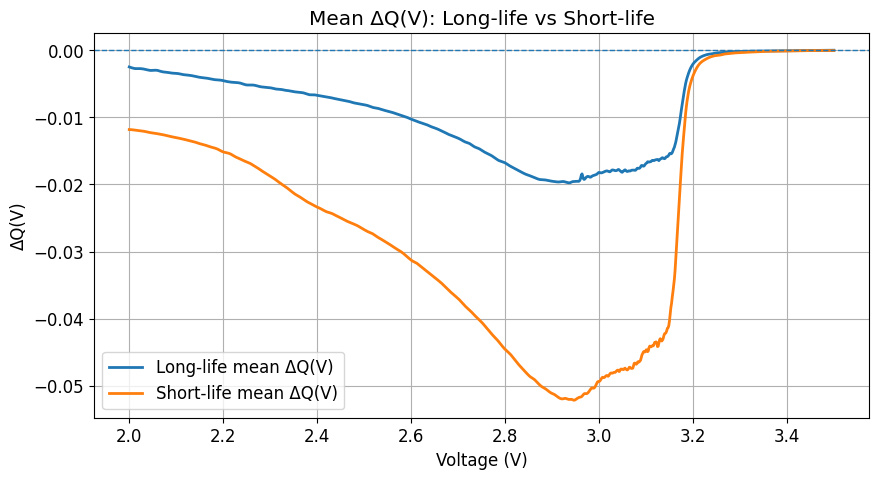

In [17]:
def stack_delta_q(curve_dict, cell_ids):
    arrs = []
    v_ref = None
    for cid in cell_ids:
        if cid in curve_dict:
            arrs.append(curve_dict[cid]['delta_q'])
            v_ref = curve_dict[cid]['V']
    if len(arrs) == 0:
        return None, None
    return v_ref, np.vstack(arrs)

long_ids = long_df['cell_id'].tolist()
short_ids = short_df['cell_id'].tolist()

v_long, long_mat = stack_delta_q(delta_q_curves2, long_ids)
v_short, short_mat = stack_delta_q(delta_q_curves2, short_ids)

plt.figure(figsize=(10, 5))

if long_mat is not None:
    plt.plot(v_long, long_mat.mean(axis=0), label='Long-life mean ΔQ(V)', linewidth=2)

if short_mat is not None:
    plt.plot(v_short, short_mat.mean(axis=0), label='Short-life mean ΔQ(V)', linewidth=2)

plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('Voltage (V)')
plt.ylabel('ΔQ(V)')
plt.title('Mean ΔQ(V): Long-life vs Short-life')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
analysis_df.groupby("charging_policy")[
    ["delta_q_abs_mean", "cycle_life"]
].mean()

,delta_q_abs_mean,cycle_life
charging_policy,,
3.6C(80%)-3.6C,0.003847,1182.0
4.4C(80%)-4.4C,0.011095,1074.0
4.8C(80%)-4.8C,0.016308,753.0
4C(80%)-4C,0.006610,1226.5
5.4C(40%)-3.6C,0.012165,966.5
5.4C(50%)-3.6C,0.012193,899.5
5.4C(50%)-3C,0.009543,847.0
5.4C(60%)-3.6C,0.012873,859.5
5.4C(60%)-3C,0.011480,799.5


In [25]:
# C-rate 숫자 추출
analysis_df["C_rate"] = analysis_df["charging_policy"].str.extract(r'(\d+\.?\d*)C').astype(float)

# ---------------------------------
# 1. C-rate vs ΔQ 관계 (기울기)
# ---------------------------------
coef_delta = np.polyfit(analysis_df["C_rate"], analysis_df["delta_q_abs_mean"], 1)[0]

# ---------------------------------
# 2. C-rate vs 수명 관계 (기울기)
# ---------------------------------
coef_life = np.polyfit(analysis_df["C_rate"], analysis_df["cycle_life"], 1)[0]

# ---------------------------------
# 3. 상관계수
# ---------------------------------
corr_delta = analysis_df["C_rate"].corr(analysis_df["delta_q_abs_mean"])
corr_life = analysis_df["C_rate"].corr(analysis_df["cycle_life"])

print("===== 핵심 요약 =====")
print(f"C-rate vs ΔQ 증가 기울기 : {coef_delta:.4f}")
print(f"C-rate vs 수명 감소 기울기 : {coef_life:.2f}")
print(f"C-rate vs ΔQ 상관계수 : {corr_delta:.3f}")
print(f"C-rate vs 수명 상관계수 : {corr_life:.3f}")

===== 핵심 요약 =====
C-rate vs ΔQ 증가 기울기 : 0.0034
C-rate vs 수명 감소 기울기 : -89.00
C-rate vs ΔQ 상관계수 : 0.589
C-rate vs 수명 상관계수 : -0.580
